# Chapter 10: Creating Text Embedding Models - Medium Tasks

This notebook covers advanced embedding training: implementing training loops, MTEB evaluation, negative sampling strategies, and hyperparameter optimization.

## Setup

Run all cells in this section to set up the environment and load the model.

Before running these cells, review the concepts from the main Chapter 10 notebook (00_Start_Here.ipynb).

### [Optional] - Installing Packages on Google Colab

If you are viewing this notebook on Google Colab, uncomment and run the following code to install dependencies.

**Note**: Use a GPU for this notebook. In Google Colab, go to Runtime > Change runtime type > Hardware accelerator > GPU > GPU type > T4.

In [1]:
%%capture
!pip install -q accelerate>=0.27.2 transformers>=4.38.2
!pip install -q sentence-transformers>=3.0.0 mteb>=1.1.2 datasets>=2.18.0

### Model Loading

In [2]:
import torch
from datasets import load_dataset, Dataset
from sentence_transformers import SentenceTransformer, losses
from sentence_transformers.trainer import SentenceTransformerTrainer
from sentence_transformers.training_args import SentenceTransformerTrainingArguments
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator

### Helper Functions

In [3]:
def create_evaluator():
    """Create standard evaluator for consistent evaluation"""
    val_sts = load_dataset('glue', 'stsb', split='validation')
    return EmbeddingSimilarityEvaluator(
        sentences1=val_sts["sentence1"],
        sentences2=val_sts["sentence2"],
        scores=[score/5 for score in val_sts["label"]],
        main_similarity="cosine"
    )

## Challenges

Complete the following tasks.

### Level: Medium

**About This Task:**

Training embeddings requires choosing the right loss function for your task. Different losses optimize for different objectives.

#### Medium Task 1: Comparing Loss Functions in Training

### Instructions

1. Prepare data for different loss functions
2. Train models with CosineSimilarityLoss and MultipleNegativesRankingLoss
3. Track training metrics
4. Compare final evaluation scores
5. Analyze which loss function works better for semantic similarity

Load and prepare training data.

In [4]:
# Load MNLI dataset
train_data = load_dataset("glue", "mnli", split="train").select(range(10_000))
train_data = train_data.remove_columns("idx")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mnli/train-00000-of-00001.parquet:   0%|          | 0.00/52.2M [00:00<?, ?B/s]

mnli/validation_matched-00000-of-00001.p(…):   0%|          | 0.00/1.21M [00:00<?, ?B/s]

mnli/validation_mismatched-00000-of-0000(…):   0%|          | 0.00/1.25M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/392702 [00:00<?, ? examples/s]

Generating validation_matched split:   0%|          | 0/9815 [00:00<?, ? examples/s]

Generating validation_mismatched split:   0%|          | 0/9832 [00:00<?, ? examples/s]

Generating test_matched split:   0%|          | 0/9796 [00:00<?, ? examples/s]

Generating test_mismatched split:   0%|          | 0/9847 [00:00<?, ? examples/s]

### Prepare Data for CosineSimilarityLoss

In [5]:
# Transform labels: entailment=1.0, neutral/contradiction=0.0
mapping = {0: 1.0, 1: 0.0, 2: 0.0}

cosine_dataset = Dataset.from_dict({
    "sentence1": train_data["premise"],
    "sentence2": train_data["hypothesis"],
    "label": [mapping[label] for label in train_data["label"]]
})

print(f"CosineSimilarityLoss dataset: {len(cosine_dataset)} examples")
print(f"Example: {cosine_dataset[0]}")

CosineSimilarityLoss dataset: 10000 examples
Example: {'sentence1': 'Conceptually cream skimming has two basic dimensions - product and geography.', 'sentence2': 'Product and geography are what make cream skimming work. ', 'label': 0.0}


### Prepare Data for MultipleNegativesRankingLoss

Your task: Prepare data with anchor, positive, and negative.

In [6]:
import random

# Filter entailment pairs only
entailment_data = train_data.filter(lambda x: x['label'] == 0)

# Fill in: Create soft negatives by shuffling
negatives = list(entailment_data["hypothesis"])
random.shuffle(negatives)

mnr_dataset = Dataset.from_dict({
    "anchor": entailment_data["premise"],
    "positive": entailment_data["hypothesis"],
    "negative": negatives
})

print(f"\nMNR dataset: {len(mnr_dataset)} examples")
print(f"Example: {mnr_dataset[0]}")

Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]


MNR dataset: 3412 examples
Example: {'anchor': 'you know during the season and i guess at at your level uh you lose them to the next level if if they decide to recall the the parent team the Braves decide to call to recall a guy from triple A then a double A guy goes up to replace him and a single A guy goes up to replace him', 'positive': 'You lose the things to the following level if the people recall.', 'negative': 'A body of my own. '}


### Train with CosineSimilarityLoss

In [7]:
# Create model
model_cosine = SentenceTransformer('bert-base-uncased')

# Loss function
loss_cosine = losses.CosineSimilarityLoss(model=model_cosine)

# Training arguments
args_cosine = SentenceTransformerTrainingArguments(
    output_dir="cosine_model",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    warmup_steps=50,
    fp16=True,
    logging_steps=50,
)

# Create evaluator
evaluator = create_evaluator()

# Train
trainer_cosine = SentenceTransformerTrainer(
    model=model_cosine,
    args=args_cosine,
    train_dataset=cosine_dataset,
    loss=loss_cosine,
    evaluator=evaluator
)

trainer_cosine.train()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ads525 (ads525-ads525) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
50,0.256300
100,0.190800
150,0.170500
200,0.172200
250,0.165300
300,0.170900
350,0.171900
400,0.167900
450,0.161300
500,0.158500


TrainOutput(global_step=625, training_loss=0.17394683227539062, metrics={'train_runtime': 154.4821, 'train_samples_per_second': 64.732, 'train_steps_per_second': 4.046, 'total_flos': 0.0, 'train_loss': 0.17394683227539062, 'epoch': 1.0})

In [8]:
# Evaluate CosineSimilarityLoss model
results_cosine = evaluator(model_cosine)
print("\nCosineSimilarityLoss Results:")
print(f"Spearman Cosine: {results_cosine['spearman_cosine']:.4f}")


CosineSimilarityLoss Results:
Spearman Cosine: 0.6949


Clear GPU memory before training next model.

In [9]:
import gc

del trainer_cosine, model_cosine, loss_cosine
gc.collect()
torch.cuda.empty_cache()

### Train with MultipleNegativesRankingLoss

Your task: Complete the training configuration.

In [10]:
# Create model
model_mnr = SentenceTransformer('bert-base-uncased')

# Fill in: Create MNR loss
loss_mnr = losses.MultipleNegativesRankingLoss(model=model_mnr)

# Fill in: Create training arguments (same as cosine)
args_mnr = SentenceTransformerTrainingArguments(
    output_dir="mnr_model",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    warmup_steps=50,
    fp16=True,
    logging_steps=50,
)

# Train
trainer_mnr = SentenceTransformerTrainer(
    model=model_mnr,
    args=args_mnr,
    train_dataset=mnr_dataset,
    loss=loss_mnr,
    evaluator=evaluator
)

trainer_mnr.train()

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
50,0.340600
100,0.081900
150,0.064900
200,0.052000


TrainOutput(global_step=214, training_loss=0.12903220046346434, metrics={'train_runtime': 42.8931, 'train_samples_per_second': 79.547, 'train_steps_per_second': 4.989, 'total_flos': 0.0, 'train_loss': 0.12903220046346434, 'epoch': 1.0})

In [11]:
# Evaluate MNR model
results_mnr = evaluator(model_mnr)
print("\nMultipleNegativesRankingLoss Results:")
print(f"Spearman Cosine: {results_mnr['spearman_cosine']:.4f}")


MultipleNegativesRankingLoss Results:
Spearman Cosine: 0.7922


### Compare Results

In [12]:
print("\n" + "="*60)
print("Comparison:")
print(f"CosineSimilarityLoss:        {results_cosine['spearman_cosine']:.4f}")
print(f"MultipleNegativesRankingLoss: {results_mnr['spearman_cosine']:.4f}")
print(f"Difference: {abs(results_cosine['spearman_cosine'] - results_mnr['spearman_cosine']):.4f}")


Comparison:
CosineSimilarityLoss:        0.6949
MultipleNegativesRankingLoss: 0.7922
Difference: 0.0973


### Questions

1. Which loss function performed better? Why might that be?

2. MNR uses in-batch negatives. How does batch size affect MNR performance?

3. When would you choose SoftmaxLoss over these two loss functions?

**About This Task:**

MTEB (Massive Text Embedding Benchmark) provides standardized evaluation across many tasks. Understanding how to use it is crucial for comparing models.

#### Medium Task 2: MTEB Benchmark Evaluation

### Instructions

1. Run MTEB evaluation on a classification task
2. Compare trained vs base model performance
3. Analyze accuracy and F1 scores
4. Test on multiple MTEB tasks
5. Understand which tasks benefit most from training

In [13]:
from mteb import MTEB

Evaluate base model on Banking77 classification.

In [23]:
# Load base model
base_model = SentenceTransformer('bert-base-uncased')

from mteb import evaluate, get_task

# Get the task object
task = get_task("Banking77Classification")

base_results = evaluate(base_model, tasks=[task])

print("\nBase Model Results:")

task_result = base_results[0]
accuracy = task_result.scores["test"][0]["main_score"]
print(f"Accuracy: {accuracy:.4f}")


Evaluating tasks:   0%|          | 0/1 [00:00<?, ?it/s]


Base Model Results:
Accuracy: 0.6347


Evaluate your trained model.

In [26]:
# Use the MNR model from Task 1
from mteb import evaluate, get_task

# Get task (reuse the same task object from before)
task = get_task("Banking77Classification")

# Evaluate
trained_results = evaluate(model_mnr, tasks=[task])

print("\nTrained Model Results:")
accuracy = trained_results[0].scores["test"][0]["main_score"]
print(f"Accuracy: {accuracy:.4f}")


Evaluating tasks:   0%|          | 0/1 [00:00<?, ?it/s]


Trained Model Results:
Accuracy: 0.7458


### Task 2a: Evaluate on Multiple Tasks

Your task: Run evaluation on 2-3 different MTEB tasks and compare.

In [27]:
# Fill in: Choose 2-3 MTEB tasks
# Options: "ToxicConversationsClassification", "EmotionClassification", etc.

multi_eval = MTEB(tasks=[
    "Banking77Classification",
    # Add more tasks here
])

# Note: This may take several minutes
# multi_results = multi_eval.run(model_mnr)

/tmp/ipython-input-4087829742.py:4: DeprecationWarning: MTEB is deprecated and will be removed in future versions. Please use the `mteb.evaluate` function instead.
  multi_eval = MTEB(tasks=[


### Task 2b: Analyze Results Structure

Explore what information MTEB returns.

In [31]:
# Examine result structure
print("Result structure:")
task_result = trained_results[0]

# Access attributes (not dictionary keys)
print(f"  Task name: {task_result.task_name}")

print("\nDetailed metrics:")
test_scores = task_result.scores["test"][0]
for metric, value in test_scores.items():
    if isinstance(value, (int, float)):
        print(f"  {metric}: {value:.4f}")


Result structure:
  Task name: Banking77Classification

Detailed metrics:
  accuracy: 0.7458
  f1: 0.7444
  f1_weighted: 0.7444
  precision: 0.7569
  precision_weighted: 0.7569
  recall: 0.7458
  recall_weighted: 0.7458
  ap: nan
  ap_weighted: nan
  main_score: 0.7458


### Questions

1. Did training improve MTEB scores? By how much?

2. Why might a model trained on MNLI transfer well to Banking77?

3. What's the difference between accuracy and F1 in the results? When does F1 matter more?

**About This Task:**

Negative samples are crucial for contrastive learning. Different strategies for creating negatives affect model quality.

#### Medium Task 3: Negative Sampling Strategies

### Instructions

1. Implement random negative sampling
2. Implement hard negative sampling (similar but wrong)
3. Compare training with different negative strategies
4. Measure the impact on evaluation metrics
5. Analyze which strategy produces better embeddings

In [32]:
# Load fresh data
train_data = load_dataset("glue", "mnli", split="train").select(range(5_000))
entailment_data = train_data.filter(lambda x: x['label'] == 0)

print(f"Entailment pairs: {len(entailment_data)}")

Entailment pairs: 1698


### Strategy 1: Random Negatives

In [33]:
import random

def create_random_negatives(data):
    """Create negatives by random shuffling"""
    negatives = list(data["hypothesis"])
    random.shuffle(negatives)

    return Dataset.from_dict({
        "anchor": data["premise"],
        "positive": data["hypothesis"],
        "negative": negatives
    })

random_neg_dataset = create_random_negatives(entailment_data)
print("Random negatives example:")
print(random_neg_dataset[0])

Random negatives example:
{'anchor': 'you know during the season and i guess at at your level uh you lose them to the next level if if they decide to recall the the parent team the Braves decide to call to recall a guy from triple A then a double A guy goes up to replace him and a single A guy goes up to replace him', 'positive': 'You lose the things to the following level if the people recall.', 'negative': 'Egypt became the first Arab state to recognize Israel in 1979 when other Arab states were aghast.'}


### Strategy 2: Hard Negatives

Your task: Create hard negatives using contradiction pairs (label=2).

In [34]:
def create_hard_negatives(entailment_data, full_data):
    """Create hard negatives from contradiction pairs"""
    # Fill in: Filter contradiction pairs
    contradiction_data = full_data.filter(lambda x: x['label'] == 2)

    # Match each entailment with a contradiction
    # For simplicity, we'll pair them sequentially
    min_len = min(len(entailment_data), len(contradiction_data))

    return Dataset.from_dict({
        "anchor": entailment_data["premise"][:min_len],
        "positive": entailment_data["hypothesis"][:min_len],
        "negative": contradiction_data["hypothesis"][:min_len]
    })

hard_neg_dataset = create_hard_negatives(entailment_data, train_data)
print("\nHard negatives example:")
print(hard_neg_dataset[0])


Hard negatives example:
{'anchor': 'you know during the season and i guess at at your level uh you lose them to the next level if if they decide to recall the the parent team the Braves decide to call to recall a guy from triple A then a double A guy goes up to replace him and a single A guy goes up to replace him', 'positive': 'You lose the things to the following level if the people recall.', 'negative': 'Heterosexuals.'}


### Compare Negative Quality

Use a pre-trained model to measure how different negatives are.

In [35]:
from sklearn.metrics.pairwise import cosine_similarity

# Load pre-trained model for comparison
comparison_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

def measure_negative_quality(dataset, num_samples=50):
    """Measure similarity between anchor and negatives"""
    similarities = []

    for i in range(min(num_samples, len(dataset))):
        anchor_emb = comparison_model.encode([dataset[i]["anchor"]])
        negative_emb = comparison_model.encode([dataset[i]["negative"]])

        sim = cosine_similarity(anchor_emb, negative_emb)[0][0]
        similarities.append(sim)

    return np.mean(similarities), np.std(similarities)

random_mean, random_std = measure_negative_quality(random_neg_dataset)
hard_mean, hard_std = measure_negative_quality(hard_neg_dataset)

print("\nNegative Quality (lower similarity = better negative):")
print(f"Random negatives: {random_mean:.4f} ± {random_std:.4f}")
print(f"Hard negatives:   {hard_mean:.4f} ± {hard_std:.4f}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

NameError: name 'np' is not defined

### Task 3a: Train with Different Negatives

Your task: Train a small model with each strategy and compare.

In [ ]:
# This is a template - training takes time, so you may want to reduce data size

def train_with_negatives(dataset, output_dir):
    """Train model with given negative strategy"""
    model = SentenceTransformer('bert-base-uncased')
    loss = losses.MultipleNegativesRankingLoss(model=model)

    args = SentenceTransformerTrainingArguments(
        output_dir=output_dir,
        num_train_epochs=1,
        per_device_train_batch_size=16,
        warmup_steps=20,
        fp16=True,
        logging_steps=50,
    )

    evaluator = create_evaluator()

    trainer = SentenceTransformerTrainer(
        model=model,
        args=args,
        train_dataset=dataset,
        loss=loss,
        evaluator=evaluator
    )

    trainer.train()
    results = evaluator(model)

    return model, results

# Uncomment to train:
# model_random, results_random = train_with_negatives(random_neg_dataset, "random_neg")
# model_hard, results_hard = train_with_negatives(hard_neg_dataset, "hard_neg")

### Questions

1. Which negative strategy produced lower anchor-negative similarity?

2. Why might hard negatives (contradictions) be better than random negatives?

3. What would be an even harder negative? How would you create "semi-hard" negatives?

**About This Task:**

Hyperparameters like batch size, learning rate, and warmup steps significantly affect training. Systematic testing finds optimal settings.

#### Medium Task 4: Hyperparameter Comparison

### Instructions

1. Test different batch sizes
2. Test different numbers of warmup steps
3. Test different numbers of epochs
4. Track evaluation scores for each configuration
5. Identify which hyperparameters have the biggest impact

In [36]:
# Prepare small dataset for quick experiments
small_train = load_dataset("glue", "mnli", split="train").select(range(2_000))
small_train = small_train.filter(lambda x: x['label'] == 0)

small_dataset = Dataset.from_dict({
    "anchor": small_train["premise"],
    "positive": small_train["hypothesis"],
})

print(f"Small dataset: {len(small_dataset)} examples")

Small dataset: 689 examples


Create a function to test hyperparameters.

In [37]:
def test_hyperparameters(batch_size, warmup_steps, num_epochs, name):
    """Train with specific hyperparameters and evaluate"""
    model = SentenceTransformer('bert-base-uncased')
    loss = losses.MultipleNegativesRankingLoss(model=model)

    args = SentenceTransformerTrainingArguments(
        output_dir=f"hyperparam_{name}",
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        warmup_steps=warmup_steps,
        fp16=True,
        logging_steps=20,
    )

    evaluator = create_evaluator()

    trainer = SentenceTransformerTrainer(
        model=model,
        args=args,
        train_dataset=small_dataset,
        loss=loss,
        evaluator=evaluator
    )

    trainer.train()
    results = evaluator(model)

    # Clean up
    del model, trainer
    torch.cuda.empty_cache()

    return results['spearman_cosine']

### Test Different Batch Sizes

In [38]:
# Test batch sizes: 8, 16, 32
batch_results = {}

for bs in [8, 16, 32]:
    print(f"\nTesting batch_size={bs}...")
    score = test_hyperparameters(
        batch_size=bs,
        warmup_steps=20,
        num_epochs=1,
        name=f"bs{bs}"
    )
    batch_results[bs] = score
    print(f"Batch size {bs}: {score:.4f}")

print("\n" + "="*60)
print("Batch Size Comparison:")
for bs, score in batch_results.items():
    print(f"  {bs:2d}: {score:.4f}")


Testing batch_size=8...


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
20,0.194200
40,0.062700
60,0.057200
80,0.036100


Batch size 8: 0.7651

Testing batch_size=16...


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
20,0.260000
40,0.072000


Batch size 16: 0.7561

Testing batch_size=32...


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
20,0.374800


Batch size 32: 0.7451

Batch Size Comparison:
   8: 0.7651
  16: 0.7561
  32: 0.7451


### Task 4a: Test Warmup Steps

Your task: Test different warmup step values.

In [39]:
# Fill in: Test warmup_steps values: 0, 20, 50
warmup_results = {}

for warmup in [0, 20, 50]:
    print(f"\nTesting warmup_steps={warmup}...")
    score = test_hyperparameters(
        batch_size=16,
        warmup_steps=warmup,
        num_epochs=1,
        name=f"warmup{warmup}"
    )
    warmup_results[warmup] = score
    print(f"Warmup {warmup}: {score:.4f}")

print("\n" + "="*60)
print("Warmup Steps Comparison:")
for warmup, score in warmup_results.items():
    print(f"  {warmup:2d}: {score:.4f}")


Testing warmup_steps=0...


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
20,0.168000
40,0.087800


Warmup 0: 0.7629

Testing warmup_steps=20...


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
20,0.260000
40,0.072000


Warmup 20: 0.7561

Testing warmup_steps=50...


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
20,0.331400
40,0.112300


Warmup 50: 0.7580

Warmup Steps Comparison:
   0: 0.7629
  20: 0.7561
  50: 0.7580


### Visualize Results

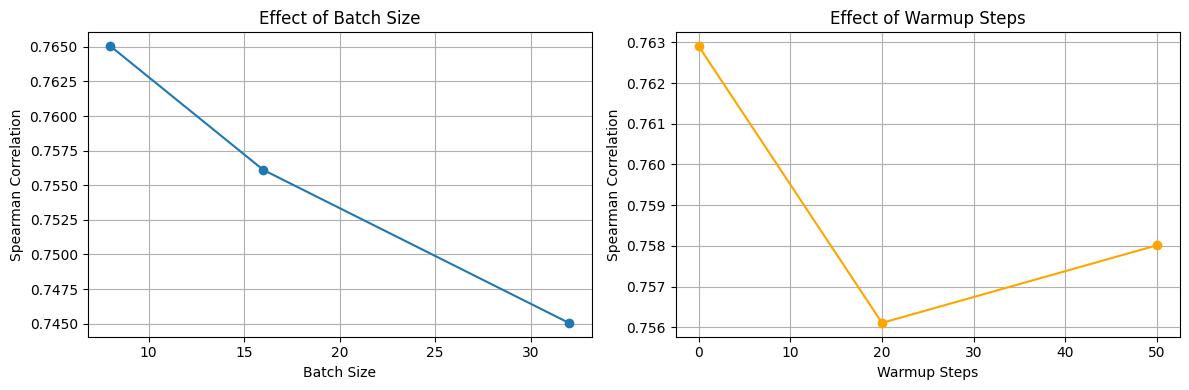

In [40]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Batch size plot
ax1.plot(list(batch_results.keys()), list(batch_results.values()), marker='o')
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Spearman Correlation')
ax1.set_title('Effect of Batch Size')
ax1.grid(True)

# Warmup plot
ax2.plot(list(warmup_results.keys()), list(warmup_results.values()), marker='o', color='orange')
ax2.set_xlabel('Warmup Steps')
ax2.set_ylabel('Spearman Correlation')
ax2.set_title('Effect of Warmup Steps')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Questions

1. Which batch size worked best? Why might larger batches help MultipleNegativesRankingLoss?

2. Did warmup steps improve performance? What does warmup prevent?

3. If you had to choose between training longer (more epochs) or larger batches, which would you pick for embedding models?